# EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 데이터 분포

In [3]:
df = pd.read_csv('../data/cookie_cats.csv')
df.sample(5)

,userid,version,sum_gamerounds,retention_1,retention_7
58165,6438250,gate_30,7,False,False
32929,3657431,gate_40,53,True,False
18610,2070768,gate_40,322,True,True
29229,3253569,gate_40,78,True,False
72589,8041733,gate_30,1,False,False


In [25]:
# 14일 간 플레이 한 스테이지에 대한 통계
df_stats = df.groupby('version').sum_gamerounds.describe().copy()
df_stats

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


cv(변동 계수)

In [5]:
df_stats['cv'] = df_stats['std'] / df_stats['mean']
df_stats

,count,mean,std,min,25%,50%,75%,max,cv
version,,,,,,,,,
gate_30,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0,4.893914
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0,2.013584


플레이 스테이지 수 desc 정렬

In [6]:
df.sort_values('sum_gamerounds', ascending=False)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
...,...,...,...,...,...
86102,9536993,gate_40,0,False,False
86092,9535396,gate_40,0,False,False
3050,336781,gate_30,0,False,False
86120,9539016,gate_30,0,False,False


그룹별 retention D1/D7에 대한 True/False 비율

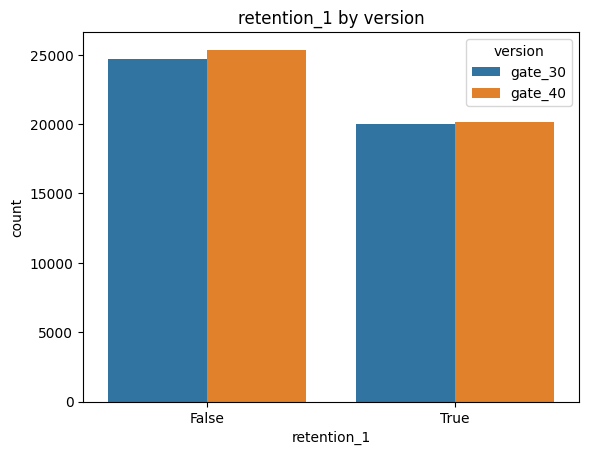

In [7]:
sns.countplot(data=df, x='retention_1', hue='version')

plt.title('retention_1 by version')
plt.show()

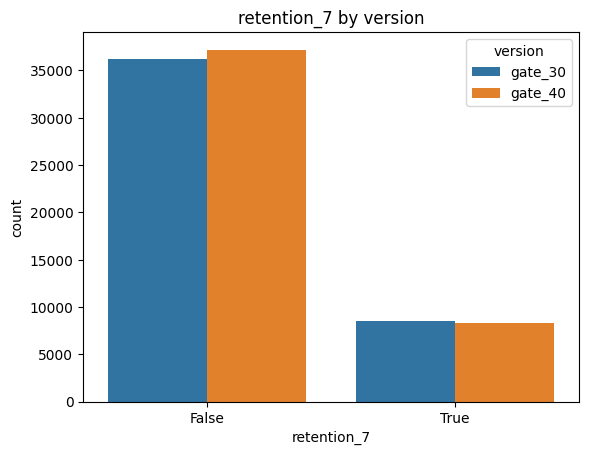

In [8]:
sns.countplot(data=df, x='retention_7', hue='version')

plt.title('retention_7 by version')
plt.show()

그룹별 retention 비율

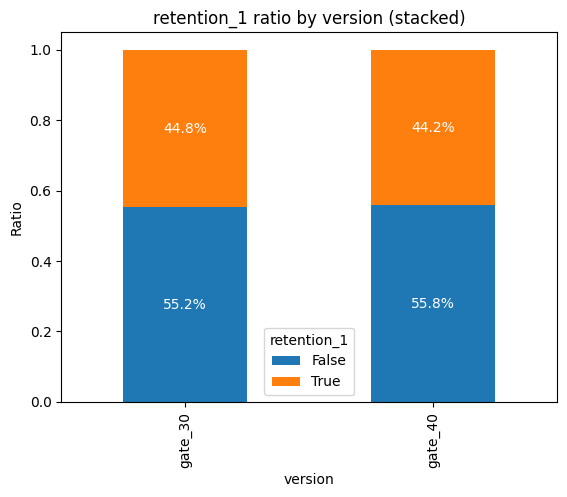

In [ ]:
ct = df.groupby(['version', 'retention_1']).size().unstack()
ct_ratio = ct.div(ct.sum(axis=1), axis=0)

ax = ct_ratio.plot(kind='bar', stacked=True)

# 비율 라벨 추가
for i, (idx, row) in enumerate(ct_ratio.iterrows()):
    cumulative = 0
    for val in row:
        if val == 0:
            continue
        
        y_pos = cumulative + val / 2
        
        ax.text(
            x=i,
            y=y_pos,
            s=f"{val:.1%}",
            ha='center',
            va='center',
            color='white'
        )
        
        cumulative += val

plt.title('retention_1 ratio by version (stacked)')
plt.ylabel('Ratio')
plt.show()

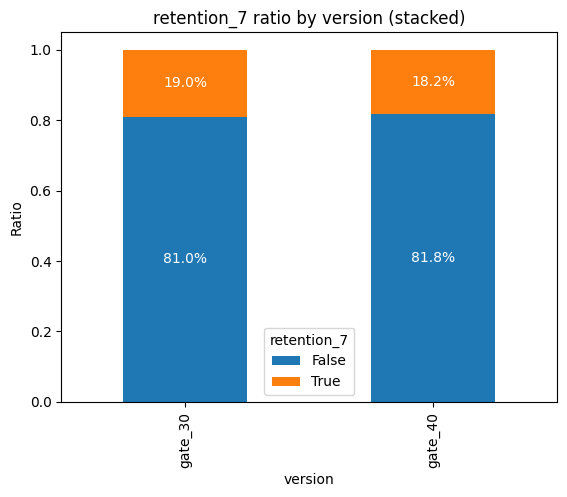

In [ ]:
# 누적 그래프로 True/False 비율
ct = df.groupby(['version', 'retention_7']).size().unstack()
ct_ratio = ct.div(ct.sum(axis=1), axis=0)

ax = ct_ratio.plot(kind='bar', stacked=True)

# 비율 라벨 추가
for i, (idx, row) in enumerate(ct_ratio.iterrows()):
    cumulative = 0
    for val in row:
        if val == 0:
            continue
        
        y_pos = cumulative + val / 2
        
        ax.text(
            x=i,
            y=y_pos,
            s=f"{val:.1%}",
            ha='center',
            va='center',
            color='white'
        )
        
        cumulative += val


plt.title('retention_7 ratio by version (stacked)')
plt.ylabel('Ratio')
plt.show()

## retention에 따른 분포

( D1 /D7 )

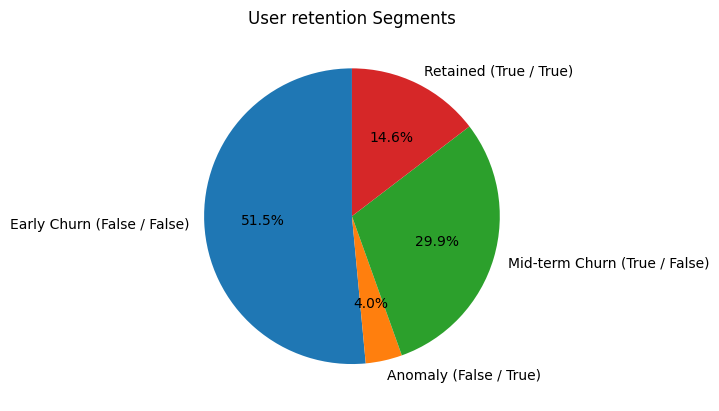

In [11]:
mask1 = (df['retention_1'] == False) & (df['retention_7'] == False)
mask2 = (df['retention_1'] == False) & (df['retention_7'] == True)
mask3 = (df['retention_1'] == True) & (df['retention_7'] == False)
mask4 = (df['retention_1'] == True) & (df['retention_7'] == True)

labels = [
    'Early Churn (False / False)',
    'Anomaly (False / True)',
    'Mid-term Churn (True / False)',
    'Retained (True / True)'
]
values = [mask1.mean(), mask2.mean(), mask3.mean(), mask4.mean()]

plt.figure()
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('User retention Segments')
plt.show()

세그먼트에 따른 그룹 비율
-> gate_30과 gate_40 비율이 유사함

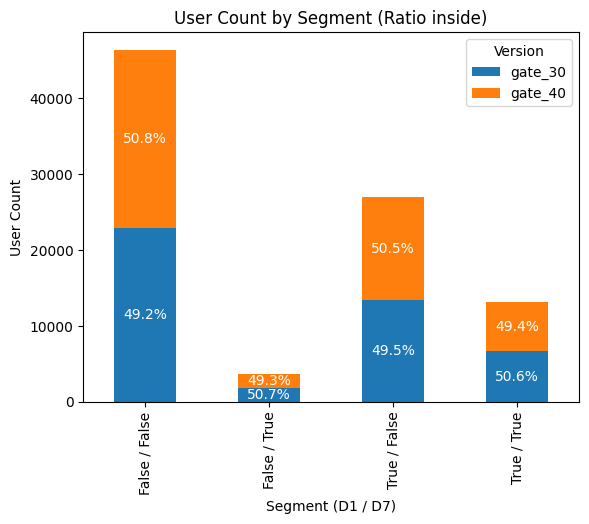

In [12]:
# segment 생성
df['segment'] = (
    df['retention_1'].astype(str) + ' / ' +
    df['retention_7'].astype(str)
)

# count 테이블
seg_count = (
    df.groupby(['segment', 'version'])
    .size()
    .unstack(fill_value=0)
)

# 순서 정리
seg_count = seg_count.loc[
    ['False / False', 'False / True', 'True / False', 'True / True']
]

# 🔥 각 segment 내 비율 (라벨용)
seg_ratio = seg_count.div(seg_count.sum(axis=1), axis=0)

# 시각화 (막대는 count)
ax = seg_count.plot(kind='bar', stacked=True)

# 🔥 라벨은 ratio
for i, segment in enumerate(seg_count.index):
    cumulative = 0
    for j, version in enumerate(seg_count.columns):
        val = seg_count.loc[segment, version]
        ratio = seg_ratio.loc[segment, version]

        if val == 0:
            continue

        y_pos = cumulative + val / 2

        ax.text(
            x=i,
            y=y_pos,
            s=f"{ratio:.1%}",   # 👈 비율 표시
            ha='center',
            va='center',
            color='white'
        )

        cumulative += val

plt.title('User Count by Segment (Ratio inside)')
plt.xlabel('Segment (D1 / D7)')
plt.ylabel('User Count')
plt.legend(title='Version')
plt.show()

## 퍼널 분석

전체 이탈

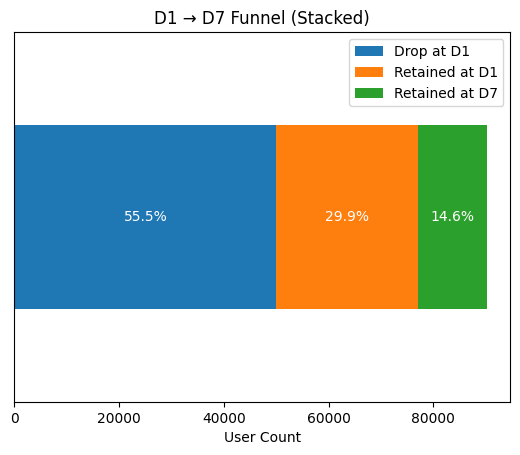

In [22]:
# 단계별 정의
total = len(df)
d1_false = df[~df['retention_1']].shape[0]  # D1 이탈 F/F + F/T
d1_true_d7_false = df[(df['retention_1']) & (~df['retention_7'])].shape[0] # T/F
d7_true = df[(df['retention_1']) & (df['retention_7'])].shape[0] # T/T


# 데이터프레임
plot_df = pd.DataFrame({
    'Drop at D1': [d1_false],
    'Retained at D1': [d1_true_d7_false],
    'Retained at D7': [d7_true]
})

# 가로 누적 막대
ax = plot_df.plot(kind='barh', stacked=True)

# 비율 라벨
total_users = plot_df.sum(axis=1)[0]
cumulative = 0

for val in plot_df.iloc[0]:
    if val == 0:
        continue
    
    ratio = val / total_users
    x_pos = cumulative + val / 2   # x축 기준으로 변경
    
    ax.text(
        x=x_pos,
        y=0,
        s=f"{ratio:.1%}",
        ha='center',
        va='center',
        color='white'
    )
    
    cumulative += val

plt.title('D1 → D7 Funnel (Stacked)')
plt.yticks([])   # y축 라벨 제거
plt.xlabel('User Count')
plt.show()

그룹별 이탈

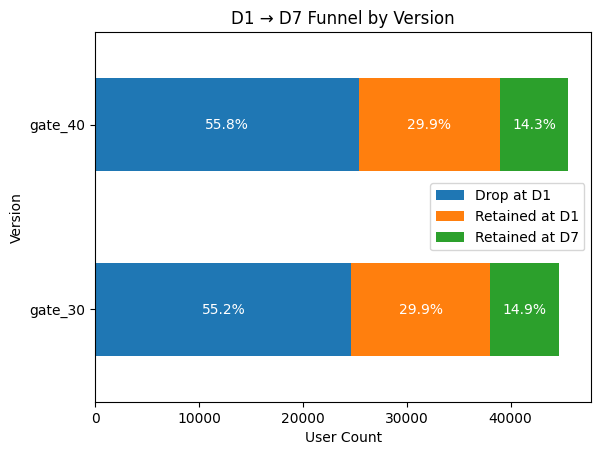

In [23]:
rows = []

for v in df['version'].unique():
    sub = df[df['version'] == v]
    
    d1_false = sub[~sub['retention_1']].shape[0]
    d1_true_d7_false = sub[(sub['retention_1']) & (~sub['retention_7'])].shape[0]
    d7_true = sub[(sub['retention_1']) & (sub['retention_7'])].shape[0]
    
    rows.append({
        'version': v,
        'Drop at D1': d1_false,
        'Retained at D1': d1_true_d7_false,
        'Retained at D7': d7_true
    })

plot_df = pd.DataFrame(rows).set_index('version')

# 가로 누적 막대 (2개)
ax = plot_df.plot(kind='barh', stacked=True)

# 각 version별 비율 라벨
for i, (idx, row) in enumerate(plot_df.iterrows()):
    total_users = row.sum()
    cumulative = 0
    
    for val in row:
        if val == 0:
            continue
        
        ratio = val / total_users
        x_pos = cumulative + val / 2
        
        ax.text(
            x=x_pos,
            y=i,
            s=f"{ratio:.1%}",
            ha='center',
            va='center',
            color='white'
        )
        
        cumulative += val

plt.title('D1 → D7 Funnel by Version')
plt.xlabel('User Count')
plt.ylabel('Version')
plt.show()

version별 retention

In [14]:
for v in df['version'].unique():
    sub = df[df['version'] == v]
    
    total = len(sub)
    d1 = sub['retention_1'].sum()
    d7 = sub[(sub['retention_1']) & (sub['retention_7'])].shape[0]
    
    print(f"\nVersion: {v}")
    print(f"D1 rate: {round(d1 / total, 2) * 100}%")
    print(f"D7 rate (from D1): {round(d7 / d1, 2) * 100}%")


Version: gate_30
D1 rate: 45.0%
D7 rate (from D1): 33.0%

Version: gate_40
D1 rate: 44.0%
D7 rate (from D1): 32.0%


## 이상치 탐지

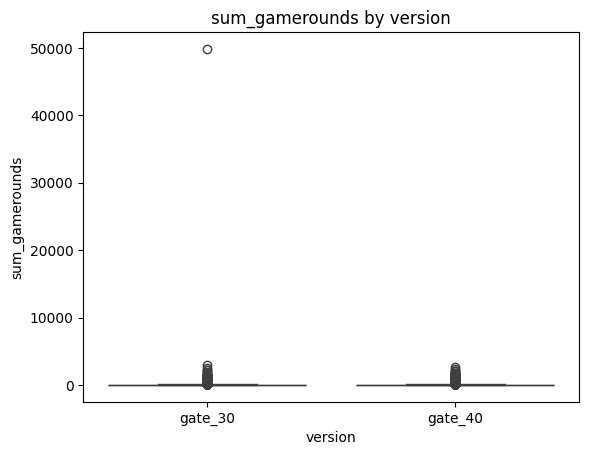

In [15]:
sns.boxplot(x='version', y='sum_gamerounds', data=df)

plt.title('sum_gamerounds by version')
plt.show()

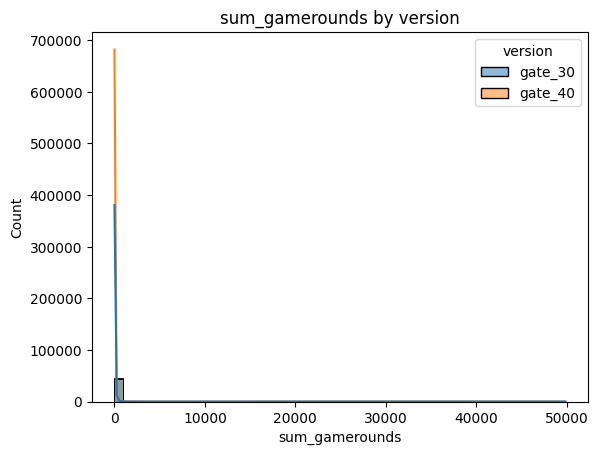

In [16]:
# 이상치 포함 플레이 스테이지 수 히스토그램
sns.histplot(data=df, x='sum_gamerounds', hue='version', bins=50, kde=True)

plt.title('sum_gamerounds by version')
plt.show()

In [17]:
# 이상치 제거 df_filtered

def remove_outliers(group):
    Q1 = group['sum_gamerounds'].quantile(0.25)
    Q3 = group['sum_gamerounds'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['sum_gamerounds'] >= lower) & (group['sum_gamerounds'] <= upper)]

df_filtered = df.groupby('version', group_keys=False).apply(remove_outliers)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79964 entries, 0 to 90188
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          79964 non-null  int64 
 1   version         79964 non-null  object
 2   sum_gamerounds  79964 non-null  int64 
 3   retention_1     79964 non-null  bool  
 4   retention_7     79964 non-null  bool  
 5   segment         79964 non-null  object
dtypes: bool(2), int64(2), object(2)
memory usage: 3.2+ MB


C:\Users\wjswl\AppData\Local\Temp\ipykernel_692\486772377.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby('version', group_keys=False).apply(remove_outliers)


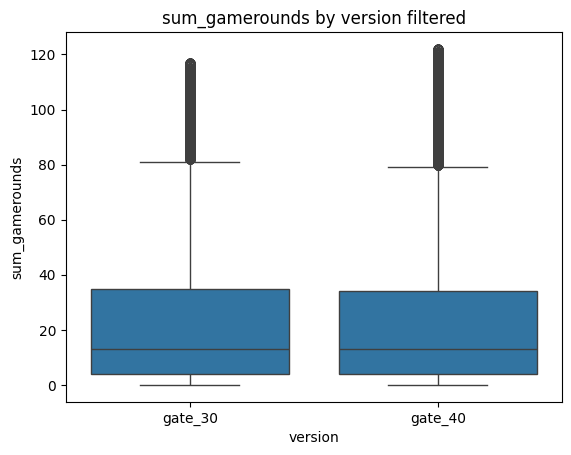

In [18]:
sns.boxplot(x='version', y='sum_gamerounds', data=df_filtered)

plt.title('sum_gamerounds by version filtered')
plt.show()

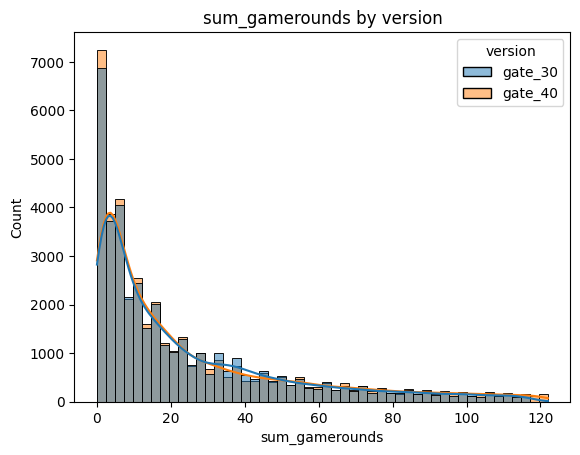

In [19]:
# 히스토그램 비교 : 두 그룹의 일반 유저의 플레이 스테이지 수가 비슷한 분포를 보임. (이상치 제외)

sns.histplot(data=df_filtered, x='sum_gamerounds', hue='version', bins=50, kde=True)

plt.title('sum_gamerounds by version')
plt.show()

- 이상치가 존재하지만, 헤비 유저의 데이터로 판단시 이상치를 제거하지 않는 것으로 한다.
- sum_gamerounds 수치에 따라 유저의 세그먼트를 구분
- sum_gamerounds가 0인 그룹만 따로 확인
---